# 04. 공모펀드(PRFD01N001) EDA

스냅샷 파일 기준일: **2026-07-11** / 원본 95,619행 × 45컬럼

---
## ⚠️ 최우선 경고 — 이 테이블의 1행은 1펀드가 아니다

**행수 95,619 vs 실제 펀드 수(itm_no) 11,139.** 한 펀드가 평균 8.6행, 최대 16행 반복된다.
반복의 원인은 `prfd_attr_cd`(펀드별속성코드) 하나뿐이고 **나머지 43개 컬럼은 전부 동일**하다.

→ **dedup 없이 `SUM(펀드 순자산)`을 계산하면 실제의 약 8.5배가 나온다.**
아래 §1에서 이를 실측으로 증명한다. 모든 집계는 `drop_duplicates('itm_no')` 이후에 수행할 것.

---

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

ROOT = Path.cwd()
while not (ROOT / "data" / "csv").exists():
    ROOT = ROOT.parent
CSV = ROOT / "data" / "csv"

df = pd.read_csv(CSV / "PRFD01N001_fund_pub_master_20260711.csv", dtype=str, keep_default_na=False)
schema = pd.read_csv(CSV / "PRFD01N001_fund_pub_schema_20260711.csv", dtype=str, keep_default_na=False)
axis = pd.read_csv(CSV / "PRFD01N001_fund_pub_axis_sample_20260711.csv", dtype=str, keep_default_na=False)
ko = dict(zip(schema.column, schema.name_ko))
print(df.shape, schema.shape, axis.shape)

(95619, 45) (45, 5) (100, 11)


In [2]:
def num(s):
    return pd.to_numeric(s, errors="coerce")

## 1. ★ 그레인 규명 — (itm_no, prfd_attr_cd) 유일키 증명

In [3]:
print("행수            :", len(df))
print("itm_no 고유     :", df.itm_no.nunique())
print("행/펀드 평균    : %.2f" % (len(df) / df.itm_no.nunique()))
print()
print("itm_no 단독 유일키?          :", df.itm_no.is_unique)
print("(itm_no, prfd_attr_cd) 중복  :", int(df.duplicated(["itm_no", "prfd_attr_cd"]).sum()), "→ 유일키 성립")

행수            : 95619
itm_no 고유     : 11139
행/펀드 평균    : 8.58

itm_no 단독 유일키?          : False
(itm_no, prfd_attr_cd) 중복  : 0 → 유일키 성립


In [4]:
# itm_no로 묶었을 때 값이 2개 이상 되는 컬럼 = 진짜 반복 축
g = df.groupby("itm_no").nunique()
varying = (g > 1).sum()
print("펀드 내부에서 값이 달라지는 컬럼:")
print(varying[varying > 0].to_string())
print("\n→ 그 외", int((varying == 0).sum()), "개 컬럼은 펀드당 완전히 동일(중복 적재)")

펀드 내부에서 값이 달라지는 컬럼:
prfd_attr_cd    11138

→ 그 외 43 개 컬럼은 펀드당 완전히 동일(중복 적재)


In [5]:
print("펀드당 행수 분포:")
print(df.itm_no.value_counts().value_counts().sort_index().to_string())

펀드당 행수 분포:
count
1        1
4      299
5      492
6     1014
7     1821
8     1991
9     1815
10    1559
11    1048
12     655
13     343
14      86
15      13
16       2


In [6]:
# 16행짜리 펀드 실물 확인
ex = df.itm_no.value_counts().index[0]
print("예시 펀드:", ex, "|", (df.itm_no == ex).sum(), "행")
df[df.itm_no == ex][["itm_no", "itm_nm", "prfd_attr_cd", "fd_nast_suma", "or_attr_desc", "sale_yn"]].reset_index(drop=True)

예시 펀드: KR5116450039 | 16 행


,itm_no,itm_nm,prfd_attr_cd,fd_nast_suma,or_attr_desc,sale_yn
0,KR5116450039,브이아이중국4차산업증권자투자신탁1호[주식]C-Pe2,F103,4231079228.0000,주식형,판매중
1,KR5116450039,브이아이중국4차산업증권자투자신탁1호[주식]C-Pe2,N143,4231079228.0000,주식형,판매중
2,KR5116450039,브이아이중국4차산업증권자투자신탁1호[주식]C-Pe2,V102,4231079228.0000,주식형,판매중
3,KR5116450039,브이아이중국4차산업증권자투자신탁1호[주식]C-Pe2,G118,4231079228.0000,주식형,판매중
4,KR5116450039,브이아이중국4차산업증권자투자신탁1호[주식]C-Pe2,F101,4231079228.0000,주식형,판매중
5,KR5116450039,브이아이중국4차산업증권자투자신탁1호[주식]C-Pe2,G110,4231079228.0000,주식형,판매중
6,KR5116450039,브이아이중국4차산업증권자투자신탁1호[주식]C-Pe2,D102,4231079228.0000,주식형,판매중
7,KR5116450039,브이아이중국4차산업증권자투자신탁1호[주식]C-Pe2,HKG,4231079228.0000,주식형,판매중
8,KR5116450039,브이아이중국4차산업증권자투자신탁1호[주식]C-Pe2,M111,4231079228.0000,주식형,판매중
9,KR5116450039,브이아이중국4차산업증권자투자신탁1호[주식]C-Pe2,CHN,4231079228.0000,주식형,판매중


In [7]:
# ★ dedup 없이 집계하면 얼마나 틀리는가
n = num(df.fd_nast_suma)
uniq = df.drop_duplicates("itm_no")
n_u = num(uniq.fd_nast_suma)
res = pd.DataFrame(
    [
        {"집계방식": "원본 그대로 SUM", "펀드 순자산 합계(조원)": round(n.sum() / 1e12, 1), "건수": len(df)},
        {"집계방식": "itm_no dedup 후 SUM", "펀드 순자산 합계(조원)": round(n_u.sum() / 1e12, 1), "건수": len(uniq)},
    ]
)
res["왜곡 배율"] = (res["펀드 순자산 합계(조원)"] / res["펀드 순자산 합계(조원)"].iloc[1]).round(3)
res

,집계방식,펀드 순자산 합계(조원),건수,왜곡 배율
0,원본 그대로 SUM,13194.2,95619,8.536
1,itm_no dedup 후 SUM,1545.8,11139,1.000


In [8]:
print("★ 왜곡 배율: %.2f배" % (n.sum() / n_u.sum()))
print("  (실제 %.0f조원 → 잘못 집계 시 %.0f조원)" % (n_u.sum() / 1e12, n.sum() / 1e12))
print()
print("펀드 수 질의도 동일:", len(df), "이라고 답하면 오답,", len(uniq), "가 정답")

★ 왜곡 배율: 8.54배


  (실제 1546조원 → 잘못 집계 시 13194조원)

펀드 수 질의도 동일: 95619 이라고 답하면 오답, 11139 가 정답


> **시사점:** `(itm_no, prfd_attr_cd)`가 유일키이며 **`prfd_attr_cd`만이 유일하게 변하는 축**이다(43개 컬럼은 펀드당 완전 동일 = 순수 중복 적재). dedup 없이 순자산을 합하면 **8.53배 과대**, "공모펀드가 몇 개냐"에 95,619라 답하면 8.6배 과대 계상이다. 온톨로지에서는 **`Fund` 인스턴스를 `itm_no` 기준으로 만들고 `prfd_attr_cd`는 다대일 부속 속성**으로 붙여야 하며, RAG의 모든 집계 쿼리는 dedup을 강제해야 한다. 이것이 이 데이터셋 최대의 함정이다.

## 2. prfd_attr_cd 228종 — 접두 패턴 사전화

In [9]:
print("prfd_attr_cd 고유:", df.prfd_attr_cd.nunique())
print()
print(df.prfd_attr_cd.value_counts().head(20).to_string())

prfd_attr_cd 고유: 228

prfd_attr_cd
C103    10943
D102    10916
C101    10559
M111    10368
M109     6955
V102     5124
V101     4667
D106     3624
W101     3138
F103     3038
G115     2062
M112     2050
G118     1687
G110     1588
V103     1342
N177      746
M106      716
CHN       646
F101      637
C102      579


In [10]:
# 형태 분류: 문자1+숫자3 / ISO3 국가코드 / 그 외(오염)
form = np.where(
    df.prfd_attr_cd.str.fullmatch(r"[A-Z]\d{3}"), "문자1+숫자3",
    np.where(df.prfd_attr_cd.str.fullmatch(r"[A-Z]{3}"), "ISO3 국가코드형", "기타(오염)"),
)
print(pd.Series(form).value_counts().to_string())
print("\n비표준 값:")
print(sorted(set(df.prfd_attr_cd[pd.Series(form).values == "기타(오염)"])))

문자1+숫자3       93948
ISO3 국가코드형     1670
기타(오염)            1

비표준 값:
['해외']


In [11]:
# 접두 문자별 사전
pref = df.prfd_attr_cd.str[0]
dic = (
    df.assign(접두=pref)
    .groupby("접두")
    .agg(행수=("itm_no", "size"), 코드종류=("prfd_attr_cd", "nunique"),
         코드예시=("prfd_attr_cd", lambda s: sorted(set(s))[:6]))
    .sort_values("행수", ascending=False)
)
dic

,행수,코드종류,코드예시
접두,,,
C,22922,5,"[C101, C102, C103, C104, CHN]"
M,21072,17,"[M101, M102, M104, M105, M106, M107]"
D,15315,6,"[D101, D102, D103, D105, D106, DEU]"
V,11264,4,"[V101, V102, V103, VNM]"
G,5505,16,"[G101, G102, G105, G106, G108, G109]"
W,5359,35,"[W101, W102, W104, W105, W106, W107]"
N,4057,60,"[N101, N102, N104, N105, N106, N107]"
F,3958,8,"[F101, F102, F103, F104, F105, F106]"
P,1708,10,"[P101, P102, P103, P104, P105, P108]"


In [12]:
# ISO3형 코드는 '투자국가'로 보이는지 교차 검증
iso = df[df.prfd_attr_cd.str.fullmatch(r"[A-Z]{3}") & ~df.prfd_attr_cd.isin([])]
print("ISO3형 코드 종류:", sorted(set(iso.prfd_attr_cd)))
print()
print(pd.crosstab(iso.prfd_attr_cd, iso.fd_ivst_rgn_desc).to_string())

ISO3형 코드 종류: ['AUS', 'BRA', 'CHN', 'DEU', 'ESP', 'FRA', 'GBR', 'HKG', 'IDN', 'IND', 'JPN', 'KOR', 'MYS', 'RUS', 'TWN', 'USA', 'VNM']

fd_ivst_rgn_desc  국내  글로벌  남미/북미  아시아  유럽  이머징/브릭스
prfd_attr_cd                                      
AUS                0    0      0    6   0        0
BRA                0   28     27    0   0       11
CHN                8  228      0  375   0       35
DEU                0    3      0    0  15        0
ESP                0    3      0    0   0        0
FRA                0    3      0    0   0        0
GBR                0    3      0    0   0        0
HKG                0    9      0   21   0        0
IDN                0    0      0   13   0        0
IND                2   41      0   43   0       56
JPN                1   45      0   88   0        0
KOR                0    7      0   16   0        0
MYS                0    6      0    0   0        0
RUS                0   11      1   17  15        9
TWN                0    7      0    0   0        0

> **시사점:** `prfd_attr_cd`는 **한 컬럼에 최소 세 가지 이질적 코드 체계가 섞여 있다** — ① `C103`류 문자1+숫자3 코드(판매채널/클래스 속성으로 추정), ② `CHN`·`USA` 같은 ISO3 국가코드(투자국가와 실제로 교차 일치), ③ `해외` 한글 1건(오염). 즉 "펀드별속성코드"라는 이름과 달리 **속성의 종류 자체가 값에 따라 달라지는 다형 컬럼**이라, 온톨로지에서 단일 속성으로 매핑하면 안 되고 **접두 규칙으로 분해해 서로 다른 관계로 승격**해야 한다.

## 3. kofia_fd_ccd 20자리 코드 — 자리 의미 역추정 (⚠️ 전부 '가설')

In [13]:
print("길이 분포:", df.kofia_fd_ccd.str.len().value_counts().to_dict())
zero = df.kofia_fd_ccd == "0" * 20
print("'0'*20 (무효):", int(zero.sum()), "행 (%.1f%%)" % (zero.mean() * 100))
print("유효 코드 행 :", int((~zero & (df.kofia_fd_ccd.str.len() == 20)).sum()))
print("고유 코드 종류:", df.loc[~zero, "kofia_fd_ccd"].nunique())

길이 분포: {20: 95515, 0: 94, 19: 10}
'0'*20 (무효): 22131 행 (23.1%)
유효 코드 행 : 73384
고유 코드 종류: 4782


In [14]:
k = df[~zero & (df.kofia_fd_ccd.str.len() == 20)].copy()
pos = pd.DataFrame(
    [{"자리": i + 1, "고유문자수": k.kofia_fd_ccd.str[i].nunique(),
      "상위 분포": dict(k.kofia_fd_ccd.str[i].value_counts().head(4))} for i in range(20)]
)
pos

,자리,고유문자수,상위 분포
0,1,2,"{'1': 72787, '2': 597}"
1,2,9,"{'2': 28863, '6': 25178, '4': 6748, '1': 6354}"
2,3,3,"{'1': 68672, '2': 3639, 'E': 1073}"
3,4,3,"{'2': 40026, '1': 25300, '3': 8058}"
4,5,4,"{'3': 47967, '1': 25405, '4': 6, '2': 6}"
5,6,19,"{'6': 23240, '4': 18262, 'A': 16141, '2': 7666}"
6,7,6,"{'1': 70534, '3': 2711, '4': 74, '9': 48}"
7,8,6,"{'2': 71858, '3': 1078, '1': 375, '6': 48}"
8,9,10,"{'0': 63244, '3': 7704, '1': 1022, '9': 389}"
9,10,9,"{'0': 32390, '6': 19390, '3': 13219, '1': 4555}"


In [15]:
# 자리별로 기존 분류 컬럼과의 교차표를 보고 의미를 추정한다.
for i, col in [(1, "or_attr_desc"), (4, "fd_ivst_rgn_desc"), (5, "fd_ivst_rgn_desc")]:
    print(f"=== {i+1}번째 자리 × {col} ({ko.get(col,'')})")
    print(pd.crosstab(k.kofia_fd_ccd.str[i], k[col]).to_string())
    print()

=== 2번째 자리 × or_attr_desc (운용속성구분코드 설명)
or_attr_desc    06   MMF  대출형  임대형    재간접    주식형  주식혼합   채권형  채권혼합  특별자산  혼합자산
kofia_fd_ccd                                                                  
1               82     0    0    0      0     48     0  6166    58     0     0
2             1975     0    0    0     72  26797     5    14     0     0     0
3              282     0    0    0     64      0  1625     7     0     0     0
4              112     0    0    0      0      0     8    41  6587     0     0
6              371     0    0    0  24537    123    84     0    63     0     0
7                0     0    5   12    806      0     0     0     0     0     0
8              380     0    0    0    205      0     0     0     0   333     0
9                0     0    0    0    527      0     0     0     0     0   922
E                0  1073    0    0      0      0     0     0     0     0     0

=== 5번째 자리 × fd_ivst_rgn_desc (펀드투자지역구분코드 설명)
fd_ivst_rgn_desc     국내    글로벌  남미/북미   아시아 

In [16]:
print("=== 4번째 자리 × exchdg_yn(환헤지여부)")
print(pd.crosstab(k.kofia_fd_ccd.str[3], k.exchdg_yn.replace("", "(결측)")).to_string())
print()
print("=== 1번째 자리 × prvo_pbff_desc(사모/공모)")
print(pd.crosstab(k.kofia_fd_ccd.str[0], k.prvo_pbff_desc).to_string())

=== 4번째 자리 × exchdg_yn(환헤지여부)
exchdg_yn      (결측)      N      Y
kofia_fd_ccd                     
1             22148   2560    592
2               155  11347  28524
3                44   2236   5778

=== 1번째 자리 × prvo_pbff_desc(사모/공모)
prvo_pbff_desc     공모
kofia_fd_ccd         
1               72787
2                 597


In [17]:
# "자리 문자를 알면 해당 분류값을 얼마나 맞힐 수 있는가"(순도)로 연동 강도를 정량화한다.
# 순도 = 자리 문자별 최빈 분류값의 비중 가중평균. baseline(=전체 최빈값 비중) 대비 개선폭을 본다.
def purity(pos_char, target):
    ct = pd.crosstab(pos_char, target)
    return ct.max(axis=1).sum() / ct.values.sum()


targets = ["or_attr_desc", "fd_ivst_rgn_desc", "ovrs_fd_desc", "exchdg_yn", "pers_corp_desc"]
base = {t: k[t].value_counts(normalize=True).max() for t in targets}
pur = pd.DataFrame(
    {t: [round(purity(k.kofia_fd_ccd.str[i], k[t]), 3) for i in range(20)] for t in targets},
    index=[f"{i+1}자리" for i in range(20)],
)
print("baseline(자리 정보 없이 최빈값으로 찍었을 때의 정답률):")
print(pd.Series(base).round(3).to_string())
pur

baseline(자리 정보 없이 최빈값으로 찍었을 때의 정답률):
or_attr_desc        0.367
fd_ivst_rgn_desc    0.442
ovrs_fd_desc        0.548
exchdg_yn           0.475
pers_corp_desc      0.747


,or_attr_desc,fd_ivst_rgn_desc,ovrs_fd_desc,exchdg_yn,pers_corp_desc
1자리,0.367,0.447,0.552,0.480,0.747
2자리,0.939,0.638,0.674,0.582,0.755
3자리,0.422,0.453,0.557,0.486,0.755
4자리,0.503,0.780,0.987,0.769,0.747
5자리,0.424,0.465,0.573,0.476,0.747
6자리,0.451,0.492,0.559,0.488,0.758
7자리,0.384,0.462,0.570,0.488,0.747
8자리,0.368,0.443,0.551,0.478,0.747
9자리,0.415,0.499,0.594,0.517,0.747
10자리,0.432,0.460,0.560,0.486,0.903


In [18]:
lift = (pur - pd.Series(base)).round(3)  # baseline 대비 개선폭
best = lift.idxmax(axis=1).to_frame("최강 연동 컬럼")
best["순도"] = [pur.loc[i, c] for i, c in best["최강 연동 컬럼"].items()]
best["baseline대비 개선"] = lift.max(axis=1)
best["해석(가설)"] = np.where(
    best["baseline대비 개선"] > 0.25, "강한 연동 — 해당 의미 자리로 추정",
    np.where(best["baseline대비 개선"] > 0.1, "약한 연동", "무관/판별불가"),
)
best

,최강 연동 컬럼,순도,baseline대비 개선,해석(가설)
1자리,fd_ivst_rgn_desc,0.447,0.005,무관/판별불가
2자리,or_attr_desc,0.939,0.572,강한 연동 — 해당 의미 자리로 추정
3자리,or_attr_desc,0.422,0.055,무관/판별불가
4자리,ovrs_fd_desc,0.987,0.439,강한 연동 — 해당 의미 자리로 추정
5자리,or_attr_desc,0.424,0.057,무관/판별불가
6자리,or_attr_desc,0.451,0.084,무관/판별불가
7자리,ovrs_fd_desc,0.570,0.022,무관/판별불가
8자리,ovrs_fd_desc,0.551,0.003,무관/판별불가
9자리,fd_ivst_rgn_desc,0.499,0.057,무관/판별불가
10자리,pers_corp_desc,0.903,0.156,약한 연동


In [19]:
print("판정 요약:")
print(best["해석(가설)"].value_counts().to_string())
print("\n순도 1.0(완전 결정)에 도달한 자리:", int((best.순도 >= 0.999).sum()))
print("→ 어떤 자리도 기존 분류 컬럼을 완전히 결정하지 못한다.")

판정 요약:
해석(가설)
무관/판별불가                 9
약한 연동                   7
강한 연동 — 해당 의미 자리로 추정    4

순도 1.0(완전 결정)에 도달한 자리: 0
→ 어떤 자리도 기존 분류 컬럼을 완전히 결정하지 못한다.


> **시사점(⚠️ 전부 가설):** `kofia_fd_ccd`는 20자리 위치기반 코드로, **`'0'×20`인 무효값이 22,131행(23.1%)**이다. 자리별 순도 분석 결과 **2·3번째 자리는 운용속성(주식형/채권형/재간접…)과, 4번째 자리는 국내외구분·환헤지와 강하게 연동**되는 것으로 보인다. 그러나 **순도 1.0에 도달하는 자리는 하나도 없어 어떤 자리도 분류값을 완전히 결정하지 못하며**, 뒷자리(16~20)는 `Z` 패딩이 지배적이라 정보량이 거의 없다. **금융투자협회 공식 코드북 없이 자리 의미를 확정하는 것은 불가능**하므로, 온톨로지에는 이 컬럼을 **원본 리터럴로만 보존**하고 파생 분류에 사용하지 않는다. 위 해석을 사실처럼 답변하면 곧바로 환각이 된다.

## 4. 클래스 계층 — 모펀드 ↔ 클래스 복원 가능성

In [20]:
# 클래스 표기는 두 가지다: 구분자가 있는 형태('…종류A', '… Class C', '…_Ce')와
# 구분자 없이 이름 끝에 바로 붙는 형태('…자주식Cw', '…중동주식자C3').
STRICT_RE = r"(?:종류|Class\s*|_)([A-Za-z][A-Za-z0-9\-]*)\s*$"
LOOSE_RE = r"([A-Za-z][A-Za-z0-9\-]{0,5})\s*$"
uniq = df.drop_duplicates("itm_no").copy()
uniq["class_strict"] = uniq.itm_nm.str.extract(STRICT_RE, expand=False)
uniq["class_tok"] = uniq.itm_nm.str.extract(LOOSE_RE, expand=False)
print("구분자 있는 형태 추출률: %.1f%% (%d건)" % (uniq.class_strict.notna().mean() * 100, uniq.class_strict.notna().sum()))
print("말미 영문토큰 전체 추출률: %.1f%% (%d건)" % (uniq.class_tok.notna().mean() * 100, uniq.class_tok.notna().sum()))
print("→ 클래스 미표기(모펀드 단일 클래스로 추정): %d건" % uniq.class_tok.isna().sum())
uniq.class_tok.value_counts().head(25).to_frame("펀드수")

구분자 있는 형태 추출률: 35.3% (3931건)
말미 영문토큰 전체 추출률: 72.0% (8025건)
→ 클래스 미표기(모펀드 단일 클래스로 추정): 3114건


,펀드수
class_tok,
C,864
A,849
Ce,431
C-Pe,424
C1,377
C-e,370
C-P,359
C2,352
C3,330


In [21]:
# 토큰을 대표 클래스 문자로 정규화 (C-Pe2 → C, A-e → A)
uniq["class_grp"] = uniq.class_tok.str.upper().str[0]
uniq.class_grp.value_counts().head(15).to_frame("펀드수")

,펀드수
class_grp,
C,5811
A,1693
L,103
F,89
E,83
P,56
I,56
S,50
W,31


In [22]:
# 모펀드 식별자 후보들의 집약도
ids = ["itm_no", "std_itm_no", "ksd_itm_no", "rptt_ksd_itm_no", "mtco_itm_no", "fss_itm_no", "or_co_xtn_itt_cd"]
pd.DataFrame(
    [
        {"컬럼": c, "한글명": ko.get(c, ""), "고유값수": int(uniq[c][uniq[c] != ""].nunique()),
         "펀드당 집약도": round(len(uniq) / max(uniq[c][uniq[c] != ""].nunique(), 1), 2),
         "결측": int((uniq[c] == "").sum())}
        for c in ids
    ]
)

,컬럼,한글명,고유값수,펀드당 집약도,결측
0,itm_no,종목번호,11139,1.00,0
1,std_itm_no,표준종목번호,11127,1.00,9
2,ksd_itm_no,예탁원종목번호,11092,1.00,47
3,rptt_ksd_itm_no,대표예탁원종목번호,2628,4.24,9
4,mtco_itm_no,운용사종목번호,4660,2.39,1
5,fss_itm_no,금융감독원종목번호,8086,1.38,1
6,or_co_xtn_itt_cd,운용회사대외기관코드,67,166.25,9


In [23]:
# ⚠️ rptt_ksd_itm_no 에는 무효 sentinel 값이 섞여 있다 → 먼저 걸러내야 한다.
print("rptt_ksd_itm_no 상위 값:")
print(uniq.rptt_ksd_itm_no.replace("", "(결측)").value_counts().head(6).to_string())
JUNK = ["KR0000000000", "000000000000", ""]
print("\n무효 sentinel에 묶인 펀드:", int(uniq.rptt_ksd_itm_no.isin(JUNK).sum()), "건 → 제외")
uniq[uniq.rptt_ksd_itm_no == "KR0000000000"][["itm_no", "itm_nm", "or_attr_desc"]].head(5)

rptt_ksd_itm_no 상위 값:
rptt_ksd_itm_no
KR0000000000    284
000000000000    192
0325700EP094     15
033180044611     15
032580007A09     15
031910537220     15

무효 sentinel에 묶인 펀드: 485 건 → 제외


,itm_no,itm_nm,or_attr_desc
28,KR5364791002,골든브릿지특별자산13,특별자산
214,KR5119251002,Tops국공채채권투자신탁1호,채권형
238,KR5019101508,신한BNPPBEST국공채신종MMF8호,MMF
334,KR5010101405,서울신종MMF5,MMF
335,KR5149450025,프론티어중동주식자C3,주식형


In [24]:
valid = uniq[~uniq.rptt_ksd_itm_no.isin(JUNK)]
sizes = valid.groupby("rptt_ksd_itm_no").size()
print("유효 대표종목번호:", len(sizes), "개 /", len(valid), "펀드 → 집약도 %.2f:1" % (len(valid) / len(sizes)))
print("\n대표종목번호당 클래스 수 분포:")
print(sizes.value_counts().sort_index().head(12).to_string())
print("\n2개 이상 묶인 그룹:", int((sizes > 1).sum()), "/ 총", len(sizes))

유효 대표종목번호: 2626 개 / 10654 펀드 → 집약도 4.06:1

대표종목번호당 클래스 수 분포:
1     749
2     483
3     231
4     242
5     155
6     151
7     113
8     183
9     116
10     75
11     52
12     31

2개 이상 묶인 그룹: 1877 / 총 2626


In [25]:
big = sizes.sort_values(ascending=False).index[0]
valid[valid.rptt_ksd_itm_no == big][["itm_no", "itm_nm", "class_tok", "or_attr_desc", "fd_nast_suma"]].head(15)

,itm_no,itm_nm,class_tok,or_attr_desc,fd_nast_suma
545,KR5148450033,피델리티글로벌금융주증권자투자신탁(주식_재간접)C-e,C-e,재간접,100379245640.0000
1415,KR5148450030,피델리티글로벌금융주증권자투자신탁(주식-재간접)C1,C1,재간접,100379245640.0000
2145,KR518105011M,피델리티글로벌금융주증권자투자신탁(주식-재간접형)CP,CP,재간접,100379245640.0000
2185,KR5148450039,피델리티글로벌금융주증권자투자신탁(주식-재간접형)종류C-w,C-w,재간접,100379245640.0000
2662,KR5148450043,피델리티글로벌금융주증권자투자신탁(주식-재간접)CG,CG,재간접,100379245640.0000
2774,KR5148450034,피델리티글로벌금융주증권자투자신탁(주식-재간접)C3,C3,재간접,100379245640.0000
3194,KR5148450032,피델리티글로벌금융주증권자투자신탁(주식-재간접)C2,C2,재간접,100379245640.0000
3569,KR5148450036,피델리티글로벌금융주증권자투자신탁(주식-재간접)C5,C5,재간접,100379245640.0000
4816,KR5148490142,피델리티글로벌금융주증권자투자신탁(주식-재간접형)CPe,CPe,재간접,100379245640.0000
5826,KR5148490190,피델리티글로벌금융주증권자투자신탁(주식-재간접형)F,F,재간접,100379245640.0000


In [26]:
# 그룹 안에서 클래스 토큰을 제거한 모펀드명이 실제로 일치하는지 검증
def stem(x):
    return re.sub(LOOSE_RE, "", re.sub(STRICT_RE, "", x)).strip().rstrip("_ -")


chk = valid.groupby("rptt_ksd_itm_no").itm_nm.apply(lambda s: len({stem(x) for x in s}) == 1)
multi = chk[sizes > 1]
print("2개 이상 묶인 그룹 중 모펀드명 완전 일치: %.1f%% (%d/%d)" % (multi.mean() * 100, multi.sum(), len(multi)))
print("전체 유효 그룹 기준 일치율      : %.1f%%" % (chk.mean() * 100))
print("\n불일치 그룹 예시:")
badg = chk[~chk].index[0]
print(valid[valid.rptt_ksd_itm_no == badg].itm_nm.head(5).to_string())

2개 이상 묶인 그룹 중 모펀드명 완전 일치: 54.2% (1018/1877)
전체 유효 그룹 기준 일치율      : 67.3%

불일치 그룹 예시:
12498    미래에셋맵스 AP 리츠 하이브리드 부동산투자신탁 1호(재간접형)(C-I)
17021         미래에셋맵스AP리츠하이브리드부동산투자신탁1호(재간접형)(C-A)


> **시사점:** 종목명 말미에서 클래스 토큰을 뽑을 수 있으나 **구분자('종류'/'Class'/'_')가 있는 형태는 35.3%뿐이고, 나머지는 `…자주식Cw`처럼 이름에 바로 붙어 있어** 느슨한 정규식으로 72.0%까지 커버된다 — 정규식 하나로는 완결되지 않는다. 모펀드 복원 키인 `rptt_ksd_itm_no`에는 **`KR0000000000`(284건)·`000000000000`(192건)이라는 무효 sentinel이 섞여 있어**, 이를 거르지 않으면 서로 무관한 펀드 284개가 한 모펀드로 묶이는 심각한 오조인이 발생한다. sentinel 제거 후에는 집약도 약 4.2:1로 `Fund`(모펀드) ↔ `FundClass`(판매 클래스) **2계층 복원이 가능**하다. 다만 그룹 내 이름 완전 일치율은 절반 수준이라(표기 흔들림: `(주식_재간접)` vs `(주식-재간접형)`) **이름이 아니라 대표종목번호를 조인키로 삼아야 한다.** `mtco_itm_no`(운용사종목번호)는 자리수가 5~7자로 들쭉날쭉해 조인키로 부적합하다.

## 5. 분류 축 실측 · 주최측 6축 대조

In [27]:
for c in ["or_attr_desc", "fd_ivst_rgn_desc", "ovrs_fd_desc", "int_dvd_desc", "pers_corp_desc", "fd_set_pcd", "curr_cd"]:
    print(f"=== {c} ({ko.get(c,'')})")
    print(uniq[c].replace("", "(결측)").value_counts().to_string(), "\n")

=== or_attr_desc (운용속성구분코드 설명)
or_attr_desc
주식형     4280
재간접     3022
채권형     1182
채권혼합    1154
06       686
주식혼합     358
MMF      250
혼합자산     133
특별자산      48
임대형       15
(결측)       9
대출형        2 

=== fd_ivst_rgn_desc (펀드투자지역구분코드 설명)
fd_ivst_rgn_desc
국내         4686
글로벌        4387
아시아        1086
남미/북미       525
이머징/브릭스     246
유럽          187
중동/아프리카      13
(결측)          9 

=== ovrs_fd_desc (해외펀드구분코드 설명)
ovrs_fd_desc
해외       5353
국내       4675
국내외혼합    1102
(결측)        9 

=== int_dvd_desc (이자배당구분코드 설명)
int_dvd_desc
배당      11128
(결측)        9
이자          2 

=== pers_corp_desc (개인법인구분코드 설명)
pers_corp_desc
해당없음    8711
개인      1763
법인       656
(결측)       9 

=== fd_set_pcd (펀드설정유형코드)
fd_set_pcd
10      10469
20        559
00        110
(결측)        1 

=== curr_cd (통화코드)
curr_cd
KRW     11067
USD        71
(결측)        1 



In [28]:
axis_cols = [c for c in axis.columns if c.startswith("axis_")]
pd.DataFrame([{"축": c, "값 분포": dict(axis[c].value_counts())} for c in axis_cols])

,축,값 분포
0,axis_fundType,"{'SecuritiesFund': 76, 'MoneyMarketFund': 7, 'MixedAsset..."
1,axis_redemptionType,"{'OpenEnded': 78, 'ClosedEnded': 22}"
2,axis_issuanceType,"{'AdditionalType': 99, 'UnitType': 1}"
3,axis_listingType,"{'Unlisted': 95, 'Listed': 5}"
4,axis_classDifferentiation,"{'SingleClass': 64, 'MultiClass': 36}"
5,axis_investorEligibility,"{'PublicOffering': 99, 'PrivateOffering': 1}"


In [29]:
pd.DataFrame(
    [
        ("axis_fundType", "or_attr_desc", "부분", "주식형/채권형/혼합/MMF/재간접 대응, 미매핑 코드 '06' 686건 별도 처리 필요"),
        ("axis_redemptionType", "(없음)", "불가", "개방형/폐쇄형(환매가능여부) 컬럼 자체가 없음"),
        ("axis_issuanceType", "fd_set_pcd", "부분", "10/20/00 코드값의 의미가 스키마에 없음 — 추가/단위형 추정"),
        ("axis_listingType", "(없음)", "불가", "상장/비상장 구분 컬럼 없음"),
        ("axis_classDifferentiation", "itm_nm 파싱 + rptt_ksd_itm_no", "부분", "§4의 클래스 토큰 추출로 근사"),
        ("axis_investorEligibility", "prvo_pbff_desc + pers_corp_desc", "가능", "공모/사모 × 개인/법인/해당없음"),
    ],
    columns=["주최측 축", "대응 후보 컬럼", "재현가능성", "비고"],
)

,주최측 축,대응 후보 컬럼,재현가능성,비고
0,axis_fundType,or_attr_desc,부분,"주식형/채권형/혼합/MMF/재간접 대응, 미매핑 코드 '06' 686건 별도 처리 필요"
1,axis_redemptionType,(없음),불가,개방형/폐쇄형(환매가능여부) 컬럼 자체가 없음
2,axis_issuanceType,fd_set_pcd,부분,10/20/00 코드값의 의미가 스키마에 없음 — 추가/단위형 추정
3,axis_listingType,(없음),불가,상장/비상장 구분 컬럼 없음
4,axis_classDifferentiation,itm_nm 파싱 + rptt_ksd_itm_no,부분,§4의 클래스 토큰 추출로 근사
5,axis_investorEligibility,prvo_pbff_desc + pers_corp_desc,가능,공모/사모 × 개인/법인/해당없음


In [30]:
# or_attr_desc의 '06' 실체 규명 — 단순 오염인가, 미매핑 코드인가?
bad06 = uniq[uniq.or_attr_desc == "06"]
print("or_attr_desc == '06' :", len(bad06), "펀드")
print("  그 중 종목명에 '파생' 포함: %.1f%%" % (bad06.itm_nm.str.contains("파생").mean() * 100))
print("  전체 펀드 기준 '파생' 포함: %.1f%%  ← 기저율" % (uniq.itm_nm.str.contains("파생").mean() * 100))
print()
print(pd.crosstab(uniq.itm_nm.str.contains("파생").rename("종목명에 '파생' 포함"), uniq.or_attr_desc).to_string())

or_attr_desc == '06' : 686 펀드
  그 중 종목명에 '파생' 포함: 98.8%
  전체 펀드 기준 '파생' 포함: 6.5%  ← 기저율

or_attr_desc      06  MMF  대출형  임대형   재간접   주식형  주식혼합   채권형  채권혼합  특별자산  혼합자산
종목명에 '파생' 포함                                                                 
False         1    8  250    2   15  2991  4278   358  1182  1149    44   133
True          8  678    0    0    0    31     2     0     0     5     4     0


In [31]:
bad06[["itm_no", "itm_nm", "or_attr_desc", "fd_ivst_rgn_desc", "zrin_fd_ivst_risk_grd_nm"]].head(8)

,itm_no,itm_nm,or_attr_desc,fd_ivst_rgn_desc,zrin_fd_ivst_risk_grd_nm
10,KR5153470243,미래에셋MSCIAC월드인덱스증권자투자신탁(주식-파생형)(H)종류C3,06,글로벌,다소 높은 위험
21,KR5114470042,삼성KOSPI200 2배레버리지증권투자신탁 제1호[주식-파생재간접형]클래스C2,06,국내,매우 높은 위험
26,KR5117474006,신한미국S&P500인덱스증권자투자신탁(H)[주식-파생형](종류C-e),06,남미/북미,높은 위험
30,KR5114601175,삼성KODEX 글로벌4차산업로보틱스증권상장지수투자신탁[주식-파생형](합성),06,국내,높은 위험
37,KR511L470002,웰컴공모주코스닥벤처기업증권투자신탁[주식혼합-파생형] 종류 A-E,06,국내,보통 위험
77,KR5153490023,미래에셋차이나A레버리지1.5증권투자신탁(주식-파생재간접형)종류C3,06,아시아,
87,KR5114470053,삼성중국본토레버리지증권자투자신탁 제1호[주식-파생재간접형]_C3,06,이머징/브릭스,매우 높은 위험
107,KR513506193M,미래에셋차이나H레버리지분할증권자투자신탁(주식-파생재간접형)종류C3,06,글로벌,


> **시사점:** 6축 중 컬럼으로 온전히 재현되는 것은 `investorEligibility` 하나뿐이다. `redemptionType`(개방형/폐쇄형)과 `listingType`(상장/비상장)은 **대응 컬럼이 아예 없어 이 RDB만으로는 축을 만들 수 없다** — 종목명 파싱이나 외부 데이터가 필요하다. 한편 `or_attr_desc`의 `06`은 **단순 오염이 아니라 한글명이 매핑되지 않은 코드값**이다: 해당 686개 펀드 중 **98.8%가 종목명에 '파생'을 포함**(전체 기저율 6.5%)하므로 **`06` = 파생형**으로 읽는 것이 타당하다. 즉 `06`을 버리면 파생형 펀드 전체가 분류에서 사라지므로, 코드→한글 매핑을 보강해 살려야 한다.

## 6. 위험등급 — ETF와 다른 체계

In [32]:
uniq.zrin_fd_ivst_risk_grd_nm.replace("", "(결측)").value_counts().to_frame("펀드수")

,펀드수
zrin_fd_ivst_risk_grd_nm,
높은 위험,3281
(결측),2573
다소 높은 위험,1663
보통 위험,1386
낮은 위험,1199
매우 높은 위험,670
매우 낮은 위험,338
높은위험,20
보통위험,8


In [33]:
print(pd.crosstab(uniq.zrin_fd_ivst_risk_gcd.replace("", "(결측)"),
                  uniq.zrin_fd_ivst_risk_grd_nm.replace("", "(결측)")).to_string())

zrin_fd_ivst_risk_grd_nm  (결측)  06  낮은 위험  높은 위험  높은위험  다소 높은 위험  매우 낮은 위험  매우 높은 위험  보통 위험  보통위험
zrin_fd_ivst_risk_gcd                                                                            
(결측)                      2573   0      0      0     0         0         0         0      0     0
00020054                     0   1      0      0     0         0         0         0      0     0
1                            0   0      0      0     0         0         0       670      0     0
2                            0   0      0   3281    20         0         0         0      0     0
3                            0   0      0      0     0      1663         0         0      0     0
4                            0   0      0      0     0         0         0         0   1386     8
5                            0   0   1199      0     0         0         0         0      0     0
6                            0   0      0      0     0         0       338         0      0     0


In [34]:
kr = pd.read_csv(CSV / "PREF01N001_etf_kr_master_20260711.csv", dtype=str, keep_default_na=False)
pd.DataFrame(
    [
        {"체계": "공모펀드(제로인)", "등급 종류": uniq.zrin_fd_ivst_risk_grd_nm.replace("", np.nan).nunique(),
         "결측률": round((uniq.zrin_fd_ivst_risk_grd_nm == "").mean(), 4),
         "값": sorted(set(uniq.zrin_fd_ivst_risk_grd_nm[uniq.zrin_fd_ivst_risk_grd_nm != ""]))},
        {"체계": "국내ETF(pd_risk_nm)", "등급 종류": kr.pd_risk_nm.nunique(),
         "결측률": round((kr.pd_risk_nm == "").mean(), 4),
         "값": sorted(set(kr.pd_risk_nm))},
    ]
)

,체계,등급 종류,결측률,값
0,공모펀드(제로인),9,0.231,"[06, 낮은 위험, 높은 위험, 높은위험, 다소 높은 위험, 매우 낮은 위험, 매우 높은 위험, 보..."
1,국내ETF(pd_risk_nm),6,0.000,"[낮은위험(5등급), 높은위험(2등급), 다소높은위험(3등급), 매우낮은위험(6등급), 매우높은위험(..."


In [35]:
# 표기 흔들림: '높은 위험'(공백 有) vs '높은위험'(공백 無)
sp = uniq.zrin_fd_ivst_risk_grd_nm
print("공백 정규화 전 종류:", sp[sp != ""].nunique())
print("공백 정규화 후 종류:", sp[sp != ""].str.replace(" ", "").nunique())
print()
print(sp[sp != ""].str.replace(" ", "").value_counts().to_string())

공백 정규화 전 종류: 9
공백 정규화 후 종류: 7

zrin_fd_ivst_risk_grd_nm
높은위험      3301
다소높은위험    1663
보통위험      1394
낮은위험      1199
매우높은위험     670
매우낮은위험     338
06           1


> **시사점:** 공모펀드는 제로인 등급명(`매우 높은 위험`~`매우 낮은 위험`)을, ETF는 `매우높은위험(1등급)` 형식을 써서 **문자열로는 두 데이터셋에 같은 질의를 걸 수 없다.** 그러나 코드 컬럼(`zrin_fd_ivst_risk_gcd`)을 보면 **1=매우 높은 위험 … 6=매우 낮은 위험으로 ETF의 1~6등급과 서열 방향이 완전히 동일**하다 — 즉 **이름이 아니라 코드로 매핑하면 두 체계를 하나의 `RiskGrade(rankOrder 1~6)` 클래스로 통합할 수 있다.** 이것이 크로스 데이터셋 위험등급 질의의 유일한 안전 경로다. 다만 같은 체계 안에서도 `높은 위험`(공백 有) vs `높은위험`(공백 無)이 공존하고(28건) 코드 컬럼에 `00020054` 같은 오염값이 있어, 정규화·화이트리스트 검증이 선행되어야 한다. 펀드 기준 결측 23.1%는 `unknown`으로 명시한다.

## 7. 판매 상태

In [36]:
print(pd.crosstab(uniq.sale_yn.replace("", "(결측)"), uniq.thco_sale_yn.replace("", "(결측)")).to_string())
print()
print("pfiv_sale_cntl_tcd(전문투자자판매제어):")
print(uniq.pfiv_sale_cntl_tcd.replace("", "(결측)").value_counts().to_string())

thco_sale_yn  (결측)  KRZ50226929C     Y
sale_yn                               
(결측)             0             1     0
판매완료           683             0  2010
판매중             11             0  8434

pfiv_sale_cntl_tcd(전문투자자판매제어):
pfiv_sale_cntl_tcd
00      11064
01         54
02         12
(결측)        9


In [37]:
# thco_sale_yn 에 종목번호가 들어간 오염
bad = df[~df.thco_sale_yn.isin(["Y", "N", ""])]
print("thco_sale_yn 비정상값:", len(bad), "행 →", bad.thco_sale_yn.unique().tolist())
bad[["itm_no", "itm_nm", "ksd_itm_no", "thco_sale_yn", "sale_yn"]]

thco_sale_yn 비정상값: 1 행 → ['KRZ50226929C']


,itm_no,itm_nm,ksd_itm_no,thco_sale_yn,sale_yn
84561,"""",공모,,KRZ50226929C,


In [38]:
sellable = (uniq.sale_yn == "판매중") & (uniq.thco_sale_yn == "Y")
print("『당사에서 현재 판매중인 공모펀드』 =", int(sellable.sum()), "/ 전체 펀드", len(uniq))
print("  판매중이나 당사 미취급:", int(((uniq.sale_yn == "판매중") & (uniq.thco_sale_yn != "Y")).sum()))
print("  판매완료               :", int((uniq.sale_yn == "판매완료").sum()))

『당사에서 현재 판매중인 공모펀드』 = 8434 / 전체 펀드 11139
  판매중이나 당사 미취급: 11
  판매완료               : 2693


> **시사점:** `sale_yn`(시장 전체 판매 여부)과 `thco_sale_yn`(당사 판매 여부)은 **다른 질문에 답하는 두 컬럼**이다. "지금 살 수 있는 펀드"는 반드시 `sale_yn=='판매중' AND thco_sale_yn=='Y'`여야 한다. `thco_sale_yn`에 예탁원 종목번호(`KRZ50226929C`)가 들어간 행이 존재해, **Y/N 화이트리스트 검증 없이 불린 캐스팅하면 조용히 오분류**된다.

## 8. 오염 종합 — ETL 검증 규칙 목록

In [39]:
print("exchdg_yn(환헤지여부):")
print(df.exchdg_yn.replace("", "(결측)").value_counts().to_string())
print("\n결측률: %.1f%%" % ((df.exchdg_yn == "").mean() * 100))

exchdg_yn(환헤지여부):
exchdg_yn
Y           44987
(결측)        29761
N           20870
00080008        1

결측률: 31.1%


In [40]:
const_cols = []
for c in df.columns:
    v = df[c][df[c] != ""]
    if v.nunique() <= 1:
        const_cols.append({"컬럼": c, "한글명": ko.get(c, ""), "유일값": v.unique().tolist(), "결측": int((df[c] == "").sum())})
pd.DataFrame(const_cols)

,컬럼,한글명,유일값,결측
0,hdge_fd_yn,헤지펀드여부,[0],66
1,ofsfd_yn,역외펀드여부,[0],1


In [41]:
print("prvo_pbff_desc(사모/공모):")
print(df.prvo_pbff_desc.replace("", "(결측)").value_counts().to_string())
print("\n→ '공모펀드' 테이블인데 사모 %d행(%d펀드)이 혼재" % (
    int((df.prvo_pbff_desc == "사모").sum()), int((uniq.prvo_pbff_desc == "사모").sum())))
print()
print(pd.crosstab(df.prvo_pbff_desc, df.prvo_fd_desc).to_string())

prvo_pbff_desc(사모/공모):
prvo_pbff_desc
공모      95451
사모        102
(결측)       66

→ '공모펀드' 테이블인데 사모 102행(15펀드)이 혼재

prvo_fd_desc        일반사모(2015년전)   해당없음
prvo_pbff_desc                         
                66             0      0
공모               0             0  95451
사모               0           102      0


In [42]:
# 오염 규칙 표
rules = pd.DataFrame(
    [
        ("prfd_attr_cd", "'해외' 한글값", int((df.prfd_attr_cd == "해외").sum()), "코드 형식 정규식 검증"),
        ("or_attr_desc", "미매핑 코드 '06'(=파생형)", int((df.or_attr_desc == "06").sum()), "코드→한글 매핑 보강(삭제 금지)"),
        ("exchdg_yn", "'00080008'", int((df.exchdg_yn == "00080008").sum()), "Y/N 화이트리스트"),
        ("exchdg_yn", "빈 문자열(결측)", int((df.exchdg_yn == "").sum()), "결측 31% → unknown 명시"),
        ("thco_sale_yn", "'KRZ50226929C' 종목번호", int((df.thco_sale_yn == "KRZ50226929C").sum()), "Y/N 화이트리스트"),
        ("zrin_fd_ivst_risk_grd_nm", "'06' 및 공백표기 불일치", int((df.zrin_fd_ivst_risk_grd_nm == "06").sum()) + int(df.zrin_fd_ivst_risk_grd_nm.isin(["높은위험", "보통위험"]).sum()), "공백 제거 후 정규화"),
        ("prvo_pbff_desc", "'사모' 혼재", int((df.prvo_pbff_desc == "사모").sum()), "공모 한정 필터 필요"),
        ("kofia_fd_ccd", "'0'*20 무효값", int((df.kofia_fd_ccd == "0" * 20).sum()), "NULL 처리"),
        ("ofsfd_yn / hdge_fd_yn", "전 행 상수 '0'", int((df.ofsfd_yn == "0").sum()), "정보량 0 → 미탑재"),
    ],
    columns=["컬럼", "오염 유형", "건수(행)", "권장 검증 규칙"],
)
rules

,컬럼,오염 유형,건수(행),권장 검증 규칙
0,prfd_attr_cd,'해외' 한글값,1,코드 형식 정규식 검증
1,or_attr_desc,미매핑 코드 '06'(=파생형),5436,코드→한글 매핑 보강(삭제 금지)
2,exchdg_yn,'00080008',1,Y/N 화이트리스트
3,exchdg_yn,빈 문자열(결측),29761,결측 31% → unknown 명시
4,thco_sale_yn,'KRZ50226929C' 종목번호,1,Y/N 화이트리스트
5,zrin_fd_ivst_risk_grd_nm,'06' 및 공백표기 불일치,239,공백 제거 후 정규화
6,prvo_pbff_desc,'사모' 혼재,102,공모 한정 필터 필요
7,kofia_fd_ccd,'0'*20 무효값,22131,NULL 처리
8,ofsfd_yn / hdge_fd_yn,전 행 상수 '0',95618,정보량 0 → 미탑재


> **시사점:** 오염은 산발적이지만 **유형이 일정하다 — 코드값이 설명 컬럼에 새어 들어오거나(`06`), 다른 컬럼의 값이 잘못 적재되거나(`KRZ50226929C`, `00080008`), 무효 sentinel(`'0'×20`)이 값처럼 들어 있다.** 건수는 적어도 전부 **자연어 질의에서 그대로 노출될 수 있는 값**이므로 위 9개 규칙을 ETL 검증으로 고정한다. 또 `ofsfd_yn`·`hdge_fd_yn`은 전 행 상수 `0`이라 정보량이 0 — 온톨로지에 싣지 않는다. **테이블 이름이 '공모펀드'인데 사모 102행이 섞여 있는 것**도 반드시 필터해야 한다.

## 9. 수익률 결측 계단 → 신규 펀드 판별

In [43]:
ern = ["fd_wk1_ern_r", "fd_mm1_ern_r", "fd_mm3_ern_r", "fd_mm6_ern_r", "fd_mm18_ern_r", "fd_yr1_ern_r", "fd_yr2_ern_r", "fd_yr3_ern_r", "fd_yr5_ern_r"]
tbl = pd.DataFrame(
    {
        "한글명": [ko.get(c, "") for c in ern],
        "결측률": [round((uniq[c] == "").mean(), 4) for c in ern],
        "유효펀드수": [int((uniq[c] != "").sum()) for c in ern],
        "중앙값": [round(num(uniq[c]).median(), 2) for c in ern],
        "min": [num(uniq[c]).min() for c in ern],
        "max": [num(uniq[c]).max() for c in ern],
    },
    index=ern,
)
tbl

,한글명,결측률,유효펀드수,중앙값,min,max
fd_wk1_ern_r,펀드 1주일수익률,0.3177,7600,0.40,-60.92,26.59
fd_mm1_ern_r,펀드 1개월수익률,0.3203,7571,0.21,-63.11,15.65
fd_mm3_ern_r,펀드 3개월수익률,0.3269,7498,7.38,-88.46,144.21
fd_mm6_ern_r,펀드 6개월수익률,0.3411,7340,10.02,-84.16,369.68
fd_mm18_ern_r,펀드 18개월수익률,0.3824,6879,25.09,-3593.02,1399.77
fd_yr1_ern_r,펀드 1년수익률,0.3701,7017,23.40,-92.57,975.10
fd_yr2_ern_r,펀드 2년수익률,0.4290,6360,33.18,-3675.44,973.95
fd_yr3_ern_r,펀드 3년수익률,0.4522,6102,47.52,-4381.56,1142.57
fd_yr5_ern_r,펀드 5년수익률,0.4991,5580,34.66,-4254.75,611.55


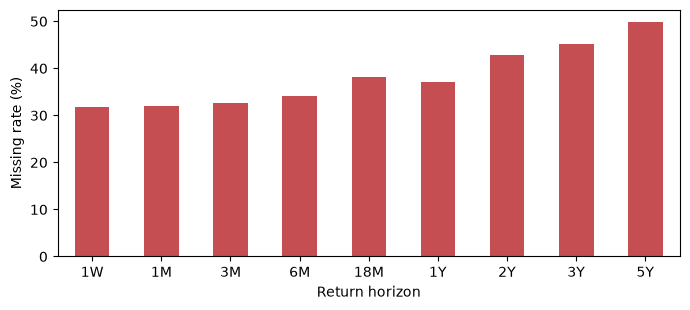

In [44]:
fig, ax = plt.subplots(figsize=(7, 3.2))
(tbl.결측률 * 100).plot.bar(ax=ax, color="#C44E52")
ax.set_xticklabels(["1W", "1M", "3M", "6M", "18M", "1Y", "2Y", "3Y", "5Y"], rotation=0)
ax.set_xlabel("Return horizon")
ax.set_ylabel("Missing rate (%)")
plt.tight_layout()
plt.show()

In [45]:
# 결측 계단 = 운용기간. 가장 긴 유효 수익률로 펀드 연차를 추정한다.
# 구간을 기간 내림차순으로 정렬해야 한다(18개월 > 1년 이므로 순서 주의)
order = ["fd_yr5_ern_r", "fd_yr3_ern_r", "fd_yr2_ern_r", "fd_mm18_ern_r", "fd_yr1_ern_r", "fd_mm6_ern_r", "fd_mm3_ern_r", "fd_mm1_ern_r", "fd_wk1_ern_r"]
age_lab = ["5년+", "3~5년", "2~3년", "18개월~2년", "1년~18개월", "6개월~1년", "3~6개월", "1~3개월", "1개월미만"]
have = uniq[order] != ""
age = pd.Series(np.select([have[c] for c in order], age_lab, default="수익률 전무"), index=uniq.index)
age.value_counts().reindex(age_lab + ["수익률 전무"]).to_frame("펀드수")

,펀드수
5년+,5580
3~5년,554
2~3년,275
18개월~2년,516
1년~18개월,166
6개월~1년,297
3~6개월,133
1~3개월,61
1개월미만,21
수익률 전무,3536


In [46]:
print("추정 신규 펀드(1년 미만 이력):", int(age.isin(["6개월~1년", "3~6개월", "1~3개월", "1개월미만"]).sum()))
print("수익률이 전혀 없는 펀드      :", int((age == "수익률 전무").sum()))
uniq.loc[age == "수익률 전무", ["itm_no", "itm_nm", "sale_yn", "fd_nast_suma"]].head(8)

추정 신규 펀드(1년 미만 이력): 512
수익률이 전혀 없는 펀드      : 3536


,itm_no,itm_nm,sale_yn,fd_nast_suma
0,KR5114420158,삼성1.5년매칭형증권투자신탁제1호[채권]_C-P,판매완료,77291400582.0000
1,KR5138490078,알리안츠다이나믹멀티에셋증권투자신탁[주식혼합_파생재간접형] Class C(F),판매완료,
3,KR5152651012,KTB글로벌테마셀렉션증권투자신탁[주식-재간접형]_C,판매완료,
6,KR5175450024,iM에셋 ALL NEW 장수기업 증권자투자신탁1호(주식)C4,판매중,7230493681.0000
10,KR5153470243,미래에셋MSCIAC월드인덱스증권자투자신탁(주식-파생형)(H)종류C3,판매중,14790135500.0000
12,KR5110450132,멀티에셋코리아베스트하이브리드증권자투자신탁[주식]Ae,판매완료,
13,KR5118430030,동양차이나RQFII중소형고배당증권자투자신탁H호(주식)ClassA,판매완료,
18,KR5114490235,삼성 글로벌액티브 적격TDF 2050증권투자신탁UH[주식혼합-재간접형]_Cf,판매중,0.0000


> **시사점:** 펀드 기준 결측률이 1주 31.8% → 5년 49.9%로 단조 증가하는 **전형적 운용기간 계단**이다. 즉 장기 수익률 결측은 데이터 품질 문제가 아니라 **"아직 그 기간을 운용하지 않았다"** 는 사실이며, 가장 긴 유효 구간으로 펀드 연차를 역산할 수 있다. 다만 **최단 구간(1주)조차 결측인 펀드가 3,536개(31.7%)** 로 가장 큰 덩어리이며, 예시를 보면 대부분 `판매완료` 상태다 — 이들은 신규가 아니라 **청산/판매종료된 잔존 레코드**다. 또 18개월·2년·3년·5년 수익률의 최솟값이 -3,000%~-4,000%대로 **명백히 비정상적인 극단값**이 섞여 있어(누적수익률 계산 오류 추정) 수익률 기반 랭킹 질의에는 값 범위 검증이 필수다. RAG는 "3년 수익률 없음"을 "정보 없음"이 아니라 "운용 3년 미만 또는 판매종료"로 구분해 답해야 한다.

## 10. 벤치마크 — 지수 엔티티 후보

In [47]:
print("bmrk_nm 고유:", uniq.bmrk_nm.nunique(), "/ bmrk_eng_nm 고유:", uniq.bmrk_eng_nm.nunique())
print("결측:", int((uniq.bmrk_nm == "").sum()))
uniq.bmrk_nm.replace("", "(결측)").value_counts().head(20).to_frame("펀드수")

bmrk_nm 고유: 391 / bmrk_eng_nm 고유: 388
결측: 0


,펀드수
bmrk_nm,
KOSPI200,1509
MSCI ACWI CR 50% + 종합채권01Y 50%,798
KOSPI200 25% + 종합채권01Y 75%,550
MSCI ACWI,399
종합채권02Y 90%,337
MSCI ACWI CR 25% + 종합채권01Y 75%,308
채권종합지수 1~2년,285
중소형지수,243
CALL,217


In [48]:
# 합성 벤치마크('A 50% + B 50%')와 단일 지수 분리
comp = uniq.bmrk_nm.str.contains(r"\+|%", regex=True)
print("합성 벤치마크(가중 조합) 펀드:", int(comp.sum()), "(%.1f%%)" % (comp.mean() * 100))
print("단일 지수 벤치마크 펀드   :", int((~comp).sum()))
print("\n단일 지수 상위:")
print(uniq.loc[~comp, "bmrk_nm"].value_counts().head(15).to_string())

합성 벤치마크(가중 조합) 펀드: 5309 (47.7%)
단일 지수 벤치마크 펀드   : 5830

단일 지수 상위:
bmrk_nm
KOSPI200                            1509
MSCI ACWI                            399
채권종합지수 1~2년                          285
중소형지수                                243
CALL                                 217
MSCI CHINA                           203
코스피 고배당 50                           164
제로인 대안투자기대수익지수                       163
MSCI ACWI Information Technology     126
종합채권 1~2년                            123
종합채권 3개월~1년                          107
MSCI AC ASIA PACIFIC ex JAPAN        103
S&P 500                               97
MSCI ACWI Health Care                 94
MSCI INDIA                            94


In [49]:
# 합성 벤치마크를 구성요소로 분해하면 실제 지수 엔티티 수는 얼마인가
parts = uniq.bmrk_nm.str.split("+").explode().str.replace(r"\s*\d+(\.\d+)?%\s*", "", regex=True).str.strip()
parts = parts[parts != ""]
print("분해 후 고유 지수명:", parts.nunique(), "(원본 조합 문자열 %d종에서)" % uniq.bmrk_nm.nunique())
parts.value_counts().head(20).to_frame("등장 횟수")

분해 후 고유 지수명: 330 (원본 조합 문자열 391종에서)


,등장 횟수
bmrk_nm,
KOSPI200,2817
종합채권01Y,2040
MSCI ACWI CR,1388
CALL,487
MSCI ACWI,471
종합채권02Y,345
Call,288
채권종합지수 1~2년,285
MSCI CHINA,268


> **시사점:** `bmrk_nm` 391종 중 **47.7%(5,309펀드)가 `MSCI ACWI CR 50% + 종합채권01Y 50%` 같은 가중 합성 문자열**이라, 문자열 그대로 두면 지수 엔티티가 조합 수만큼 폭발한다. `+`와 `%`로 분해하면 391종 → 고유 지수 330종이 되고 `KOSPI200`이 2,817회로 최다 등장 지수임이 드러난다. 다만 분해 결과에도 `CALL`/`Call`, `종합채권01Y`/`종합채권 01Y`/`KIS채권종합01Y` 같은 **동일 지수의 표기 흔들림**이 남아 있어 지수 노드 생성 전 정규화 사전이 필요하다. 온톨로지에서는 **`BenchmarkIndex` 노드와 `BenchmarkComposition`(지수+비중) 중간 노드로 분리**해야 "KOSPI200을 추종하는 펀드"류 질의가 합성 벤치마크 펀드까지 포괄한다. ETF의 `cu_base_index`(국내 95% 결측)와 달리 펀드 벤치마크는 결측이 없어, **지수 엔티티의 주요 공급원은 ETF가 아니라 공모펀드 쪽**이다.

## 종합

| 항목 | 실측 | 온톨로지/RAG 영향 |
|---|---|---|
| **그레인** | 95,619행 = 11,139펀드 × prfd_attr_cd | **dedup 없으면 순자산 8.53배 과대** |
| prfd_attr_cd | 228종, 3개 코드체계 혼재 | 접두 규칙으로 분해 후 승격 |
| kofia_fd_ccd | 20자리, 23.1% 무효 | 코드북 부재 → 원본 보존만, 파싱 금지 |
| 클래스 계층 | 유효 대표종목번호 2,626개 ↔ 10,654 클래스 (집약도 4.06:1) | sentinel 485건 제외 후 2계층 복원 가능 |
| 축 재현 | 6축 중 완전 재현 1축 | redemptionType·listingType은 불가 |
| or_attr_desc '06' | 686펀드, 98.8%가 파생형 | 오염 아닌 미매핑 코드 — 살려야 함 |
| 위험등급 | 제로인 1~6, 결측 23.1%(펀드기준) | **코드 기준 서열이 ETF와 동일** → 코드로 통합 매핑 |
| 사모 혼재 | 102행 | 공모 한정 필터 필수 |
| 벤치마크 | 391종(47.7% 합성), 분해 시 330종, 결측 0 | 지수 엔티티의 주 공급원 |